<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 6, TSMixer**

Instalamos lo necesario

In [ ]:
!pip install -q neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.5 MB/s eta 0:00:00


Importamos lo necesario

In [ ]:
%matplotlib inline
import warnings, logging, time
warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import TSMixer, PatchTST
from neuralforecast.losses.pytorch import MAE

Hiperparámetros

In [ ]:
H, L = 96, 336 # H = horizonte a predecir, L = ventana de historia
SEASON = 168  # periodo estacional del baseline: 1 semana = 168 h
N_TRAIN, VAL, TEST = 8640, 2880, 2880  # split
COLS = ["HUFL", "HULL", "MUFL", "MULL", # High/Middle/Low UseFul & UseLess load
        "LUFL", "LULL", "OT"] # OT = Oil Temperature, la variable objetivo clasica

Podemos usar el dataset directamente desde su repo oficial

In [ ]:
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
raw = (pd.read_csv(URL, parse_dates=["date"]).iloc[: N_TRAIN + VAL + TEST].copy())

Podemos hacer la estandarización z-score manual

In [ ]:
tr = raw[COLS].iloc[:N_TRAIN]
raw[COLS] = (raw[COLS] - tr.mean()) / tr.std()

Ponemos en formato de neuralforecast

In [ ]:
Y_df = (raw.melt(id_vars="date", value_vars=COLS,
                 var_name="unique_id", value_name="y")
           .rename(columns={"date": "ds"})
           .sort_values(["unique_id", "ds"])
           .reset_index(drop=True))

Entrenamos y evaluamos

In [ ]:
nf = NeuralForecast(freq="h", models=[
    TSMixer(
        h=H,  # cuantos pasos predice de una sola vez (forecast directo, no autoregresivo)
        input_size=L,  # cuantos pasos de historia entran al MLP
        n_series=len(COLS),  # TSMixer es multivariado, procesa las 7 series juntas en cada batch
        n_block=4, # bloques apilados de [time-mixing MLP + feature-mixing MLP]
        ff_dim=64, # ancho de la capa oculta del MLP que mezcla variables
        dropout=0.1, # regularizacion dentro de cada bloque
        revin=True,
        loss=MAE(), # optimizamos L1: menos sensible a outliers que MSE
        learning_rate=1e-3,
        max_steps=1000,  # tope de pasos de gradiente
        val_check_steps=50,  # evalua en validacion cada 50 pasos
        early_stop_patience_steps=5,
        batch_size=32,
        random_seed=42,
        enable_progress_bar=False,
    ),

    PatchTST(
        h=H,
        input_size=L,
        patch_len=16,           # longitud de cada parche (token)
        stride=8,               # solapamiento entre parches
        encoder_layers=3,       # capas del encoder Transformer
        n_heads=4,              # cabezas de atencion
        hidden_size=128,        # dimension del embedding de cada parche (d_model)
        linear_hidden_size=256, # ancho del feed-forward interno
        dropout=0.2,
        head_dropout=0.0,
        attn_dropout=0.0,
        revin=True,             # normalizacion reversible por ventana
        loss=MAE(),
        learning_rate=1e-3,
        max_steps=1000,
        val_check_steps=50,
        early_stop_patience_steps=5,
        batch_size=32,
        random_seed=42,
        enable_progress_bar=False,
    ),
])

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42


In [ ]:
cv = nf.cross_validation(df=Y_df, val_size=VAL, test_size=TEST,
                         n_windows=None, step_size=H).reset_index()

In [ ]:
cv = cv.drop(columns=[c for c in ("index", "level_0") if c in cv.columns])
cv = cv.sort_values(["unique_id", "cutoff", "ds"]).reset_index(drop=True)

Para medir como se degrada el error con el horizonte

In [ ]:
cv["paso"] = cv.groupby(["unique_id", "cutoff"]).cumcount() + 1

Baseline

In [ ]:
lookup = Y_df.set_index(["unique_id", "ds"])["y"] # tabla (serie, timestamp) a valor
idx = pd.MultiIndex.from_arrays([cv.unique_id,
                                 cv.ds - pd.Timedelta(hours=SEASON)])
cv["SNaive"] = lookup.reindex(idx).to_numpy()

Metricas

In [ ]:
def metricas(pred):
    """MAE / MSE / RMSE globales sobre todas las series y ventanas del test."""
    e = pred - cv["y"]
    return e.abs().mean(), (e ** 2).mean(), np.sqrt((e ** 2).mean())

In [ ]:
mae_ts, mse_ts, rmse_ts = metricas(cv["TSMixer"])

mae_pt, mse_pt, rmse_pt = metricas(cv["PatchTST"])

mae_sn, mse_sn, rmse_sn = metricas(cv["SNaive"])

In [ ]:
print(f"{'':14s}{'MAE':>8s}{'MSE':>9s}{'RMSE':>9s}")
print(f"{'TSMixer':14s}{mae_ts:8.4f}{mse_ts:9.4f}{rmse_ts:9.4f}")
print(f"{'PatchTST':14s}{mae_pt:8.4f}{mse_pt:9.4f}{rmse_pt:9.4f}")
print(f"{'SeasonalNaive':14s}{mae_sn:8.4f}{mse_sn:9.4f}{rmse_sn:9.4f}")
print(f"Mejora de TSMixer  sobre el baseline: {100*(1 - mae_ts/mae_sn):5.1f}% de MAE")
print(f"Mejora de PatchTST sobre el baseline: {100*(1 - mae_pt/mae_sn):5.1f}% de MAE")
print(f"PatchTST vs TSMixer: {100*(1 - mae_pt/mae_ts):+5.1f}% de MAE "
      f"({'PatchTST mejor' if mae_pt < mae_ts else 'TSMixer mejor'})")

# MAE promedio por paso del horizonte (1..96 h) para cada metodo.
por_paso = (cv.assign(ts=(cv["TSMixer"]  - cv["y"]).abs(),
                      pt=(cv["PatchTST"] - cv["y"]).abs(),
                      sn=(cv["SNaive"]   - cv["y"]).abs())
              .groupby("paso")[["ts", "pt", "sn"]].mean())


                   MAE      MSE     RMSE
TSMixer         0.4079   0.4033   0.6351
PatchTST        0.4075   0.4062   0.6374
SeasonalNaive   0.5127   0.6753   0.8218
Mejora de TSMixer  sobre el baseline:  20.4% de MAE
Mejora de PatchTST sobre el baseline:  20.5% de MAE
PatchTST vs TSMixer:  +0.1% de MAE (PatchTST mejor)


Grafica

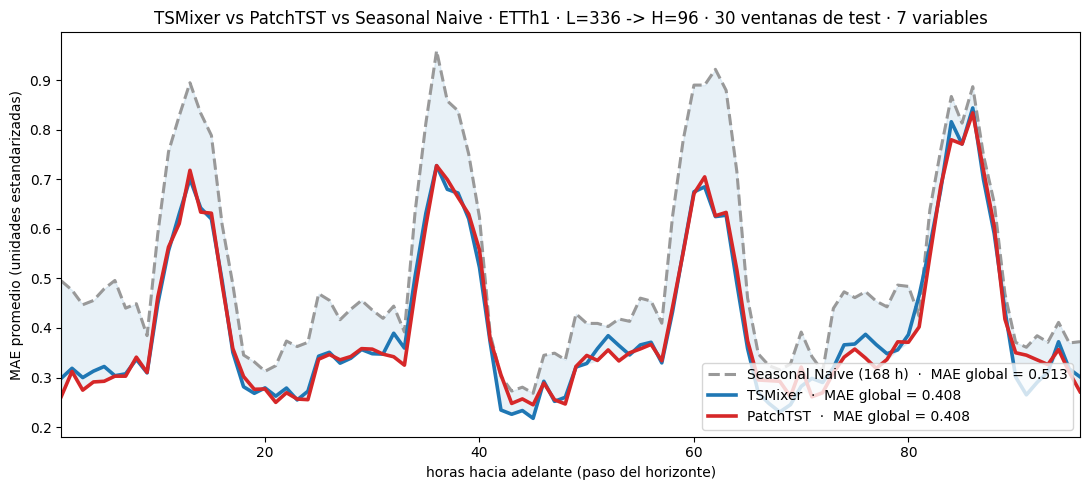

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(por_paso.index, por_paso["sn"], color="#999999", lw=2.2, ls="--",
        label=f"Seasonal Naive (168 h)  ·  MAE global = {mae_sn:.3f}")
ax.plot(por_paso.index, por_paso["ts"], color="#1f77b4", lw=2.6,
        label=f"TSMixer  ·  MAE global = {mae_ts:.3f}")
ax.plot(por_paso.index, por_paso["pt"], color="#d62728", lw=2.6,
        label=f"PatchTST  ·  MAE global = {mae_pt:.3f}")
# El area sombreada entre el mejor modelo y el baseline es el valor que aportan
ax.fill_between(por_paso.index, por_paso[["ts", "pt"]].min(axis=1), por_paso["sn"],
                color="#1f77b4", alpha=0.10)
ax.set_xlabel("horas hacia adelante (paso del horizonte)")
ax.set_ylabel("MAE promedio (unidades estandarizadas)")
ax.set_xlim(1, H)
ax.set_title("TSMixer vs PatchTST vs Seasonal Naive · ETTh1 · L=336 -> H=96 · "
             f"{TEST // H} ventanas de test · 7 variables", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
fig.tight_layout(); plt.show()

Real vs predicciones en una ventana de test

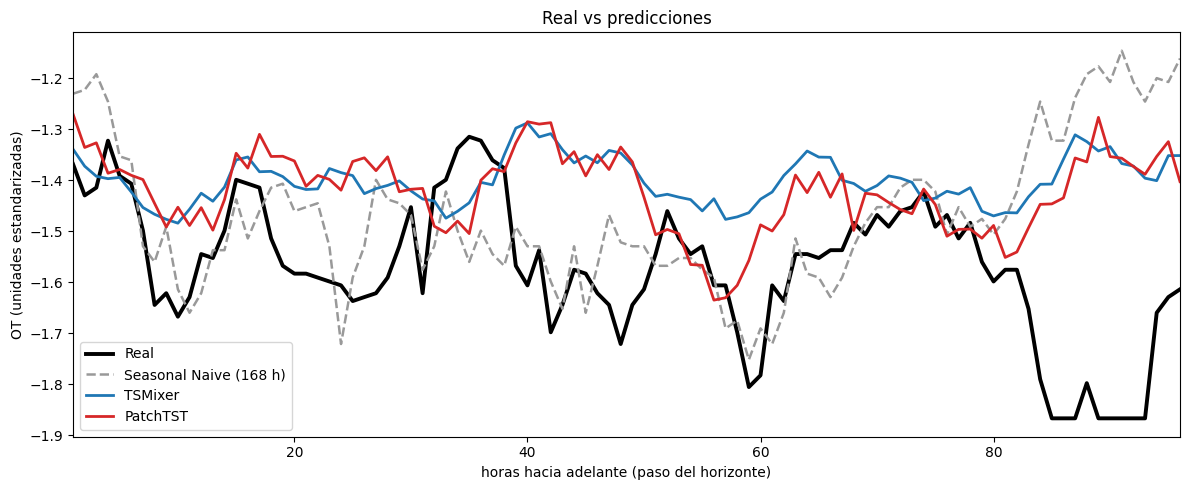

In [ ]:
VAR    = "OT" # variable a graficar
CUTOFF = sorted(cv.cutoff.unique())[-1] # ventana a graficar (ultima)

w = cv[(cv.unique_id == VAR) & (cv.cutoff == CUTOFF)].sort_values("ds")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(w["paso"], w["y"],        color="black",   lw=2.8, label="Real")
ax.plot(w["paso"], w["SNaive"],   color="#999999", lw=1.8, ls="--", label="Seasonal Naive (168 h)")
ax.plot(w["paso"], w["TSMixer"],  color="#1f77b4", lw=2.0, label="TSMixer")
ax.plot(w["paso"], w["PatchTST"], color="#d62728", lw=2.0, label="PatchTST")

ax.set_xlabel("horas hacia adelante (paso del horizonte)")
ax.set_ylabel(f"{VAR} (unidades estandarizadas)")
ax.set_xlim(1, H)
ax.set_title(f"Real vs predicciones")
ax.legend(fontsize=10, loc="best")
fig.tight_layout(); plt.show()